In [38]:
import eispac 
import sunpy 
import sunpy.map 
from sunpy.coordinates import (propagate_with_solar_surface,
                               SphericalScreen)
import sunkit_image
import sunkit_image.coalignment as coalignment
import matplotlib
import matplotlib.pyplot as plt 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from skimage.registration import phase_cross_correlation
from astropy.visualization import ImageNormalize, AsinhStretch
import astropy.units as u
import numpy as np 

In [2]:
l1_filename = "../data/eis_20221025_002341.data.h5"
eis_cube = eispac.read_cube(l1_filename, 195)

Data file,
   /home/yjzhu/Solar/learn_python_pmod/data/eis_20221025_002341.data.h5
Header file,
   /home/yjzhu/Solar/learn_python_pmod/data/eis_20221025_002341.head.h5
Found a wavelength 195.00 [Angstroms] in window 8


In [3]:
FeXII_template_filename = "../data/eis/fe_12_195_119.1c.template.h5"
eis_FeXII_195_template = eispac.read_template(FeXII_template_filename)

In [4]:
eis_FeXII_195_fitres = eispac.fit_spectra(eis_cube, template=eis_FeXII_195_template,
                                         ncpu=4)

 + computing fits for 62 exposures, each with 512 spectra
 + running mpfit on 4 cores (of 4)
 + working on exposure 060 + working on exposure 005 + working on exposure 009 + working on exposure 013 + working on exposure 014

Finished computing fits!
   runtime : 0:00:32.564669
   30720 spectra fit without issues
   1024 spectra have < 7 good data points
   0 spectra have bad or invalid parameters


/home/yjzhu/anaconda3/envs/sunpy/lib/python3.12/site-packages/eispac/core/fit_spectra.py:428: RuntimeWarning: invalid value encountered in divide
  rel_err = obs_errs/obs_cent


In [5]:
FeXII_195_intmap = eis_FeXII_195_fitres.get_map(component=0, measurement="intensity")

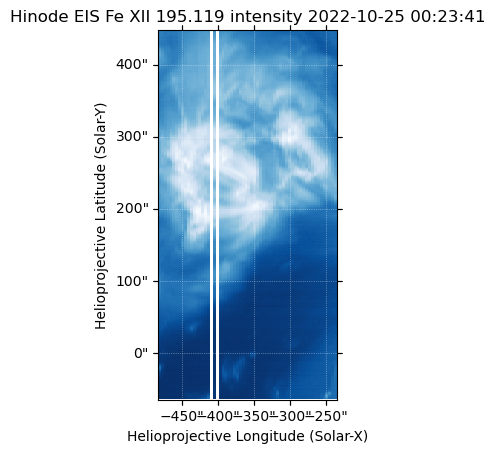

In [6]:
FeXII_195_intmap.plot()

In [12]:
aia_map = sunpy.map.Map("../../data/aia.lev1_euv_12s.2022-10-25T002339Z.193.image.fits")
aia_map.meta['rsun_ref'] = 695700000. #set the solar radius consistent with EIS

In [16]:
with propagate_with_solar_surface():
    aia_map_reproj_to_eis = aia_map.reproject_to(FeXII_195_intmap.wcs)

aia_map_reproj_to_eis.plot_settings['aspect'] = FeXII_195_intmap.plot_settings['aspect'] # change the default aspect ratio to match EIS

2026-03-23 12:48:07 - reproject.common - INFO: Calling _reproject_full in non-dask mode


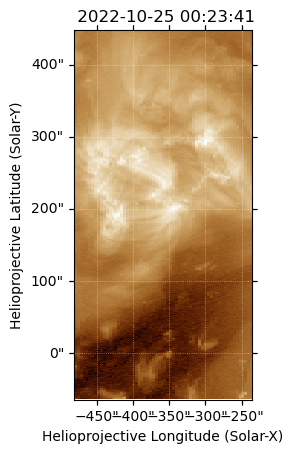

In [17]:
aia_map_reproj_to_eis.plot()

In [20]:
# a handy function to blink between the two maps to check the coalignment

class SunBlinker():
    def __init__(self, map1, map2, reproject=False, fps=5, figsize=(5,5),
                 norm1=None, norm2=None, save_fname=None) -> None:
        self.map1 = map1
        if reproject:
            self.map2 = map2.reproject_to(map1.wcs)
        else:
            self.map2 = map2
        self.fps = fps
        self.figsize = figsize

        if norm1 is None:
            self.norm1 = self.map1.plot_settings['norm']
        else:
            self.norm1 = norm1

        if norm2 is None:
            self.norm2 = self.map2.plot_settings['norm']
        else:
            self.norm2 = norm2

        self._init_plot()

        self.anim = FuncAnimation(self.fig, self._update_plot, interval=1000/self.fps, blit=True,frames=2,
                                  repeat=True)
        
        self.anim_html = HTML(self.anim.to_jshtml())

        if save_fname is not None:
            self.anim.save(save_fname, writer='imagemagick', fps=self.fps)

        if matplotlib.get_backend() == 'qtagg':
            plt.show()
        else:
            self.fig.clf()
            plt.close()

            display(self.anim_html)


    
    def _init_plot(self):
        self.fig = plt.figure(figsize=self.figsize)
        self.ax = self.fig.add_subplot(111, projection=self.map1)
        if 'aspect' in self.map1.plot_settings.keys():
            self.ax.set_aspect(self.map1.plot_settings['aspect'])
        self.im = self.map1.plot(axes=self.ax)
        self.ax.set_title(None)

    def _update_plot(self,i):
        # self.ax.clear()   
        if i == 0:
            self.im.set_array(self.map1.data)
            self.im.set_norm(self.norm1)
            self.im.set_cmap(self.map1.plot_settings['cmap'])
        else:
            self.im.set_array(self.map2.data)
            self.im.set_norm(self.norm2)
            self.im.set_cmap(self.map2.plot_settings['cmap'])
        
        return [self.im]

In [23]:
SunBlinker(FeXII_195_intmap, aia_map_reproj_to_eis, fps=2)

2026-03-23 12:49:53 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [39]:
# there appears to be a good coalignment with a tiny offset
# so we use cross correlation to find the offset and apply it to the EIS map
# there are varies of ways to do this, here we use the sunkit-image implementation
# which is a wrapper around `skimage.feature.match_template` using a fast normalized correlation algorithm.
# or you may use `skimage.registration.phase_cross_correlation` or other similar functions

def coalign_shift(big_map, small_map):
    yshift, xshift = coalignment._calculate_shift(big_map.data, small_map.data)
    reference_coord = big_map.pixel_to_world(xshift, yshift)
    Txshift = reference_coord.Tx - small_map.bottom_left_coord.Tx
    Tyshift = reference_coord.Ty - small_map.bottom_left_coord.Ty

    return Txshift, Tyshift

In [26]:
FeXII_195_intmap.data.shape

(512, 62)

In [31]:
# lets first made a cutout of EIS to avoid the bad rasters 

FeXII_195_intmap_cutout = FeXII_195_intmap.submap(
    bottom_left=[24,20]*u.pixel,
    top_right=[61,480]*u.pixel
)

2026-03-23 12:55:07 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-23 12:55:07 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


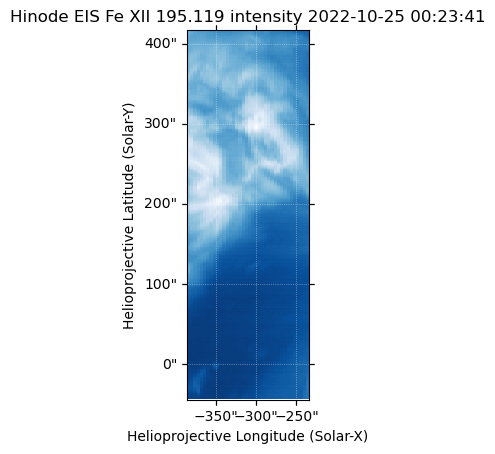

In [32]:
# preview the cutout map 

FeXII_195_intmap_cutout.plot()

In [33]:
Txshift, Tyshift = coalign_shift(aia_map_reproj_to_eis, FeXII_195_intmap_cutout)

In [34]:
print(f"Calculated shift: Tx={Txshift.to(u.arcsec)}, Ty={Tyshift.to(u.arcsec)}")

Calculated shift: Tx=5.164183676242828e-07 arcsec, Ty=-3.6166892007894944 arcsec


In [35]:
# shift the EIS map
FeXII_195_intmap_shifted = FeXII_195_intmap.shift_reference_coord(Txshift, Tyshift)

In [37]:
# Now lets compare the coaligned map with AIA again
# which looks much better now!

with propagate_with_solar_surface():
    aia_map_reproj_to_eis_shifted = aia_map.reproject_to(FeXII_195_intmap_shifted.wcs)
SunBlinker(FeXII_195_intmap_shifted, aia_map_reproj_to_eis_shifted, fps=2)

2026-03-23 12:57:11 - reproject.common - INFO: Calling _reproject_full in non-dask mode
2026-03-23 12:57:11 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


In [49]:
def coalign_shift_phase_corr(ref_map, mov_map, upsample_factor=10):
    ref_data = ref_map.data
    mov_data = mov_map.data
    mask_ref = np.isfinite(ref_data)
    mask_mov = np.isfinite(mov_data)
    shift, _, _ = phase_cross_correlation(ref_map.data, mov_map.data, upsample_factor=upsample_factor,
                                           reference_mask=mask_ref, moving_mask=mask_mov)
    yshift, x_shift = shift
    Txshift = x_shift * ref_map.scale[0] * u.pix
    Tyshift = yshift * ref_map.scale[1] * u.pix
    return Txshift, Tyshift

In [50]:
Txshift_phase, Tyshift_phase = coalign_shift_phase_corr(aia_map_reproj_to_eis, FeXII_195_intmap, upsample_factor=10) # here we use the full map without cutout 

In [51]:
print(f"Calculated shift: Tx={Txshift_phase.to(u.arcsec)}, Ty={Tyshift_phase.to(u.arcsec)}") # similar results within 1 arcsec 

Calculated shift: Tx=0.0 arcsec, Ty=-3.000000000000024 arcsec


In [52]:
with propagate_with_solar_surface():
    FeXII_195_intmap_shifted_phase = FeXII_195_intmap.shift_reference_coord(Txshift_phase, Tyshift_phase)
    aia_map_reproj_to_eis_shifted_phase = aia_map.reproject_to(FeXII_195_intmap_shifted_phase.wcs)

SunBlinker(FeXII_195_intmap_shifted_phase, aia_map_reproj_to_eis_shifted_phase, fps=2)

2026-03-23 13:07:47 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-23 13:07:47 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-03-23 13:07:47 - reproject.common - INFO: Calling _reproject_full in non-dask mode


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2026-03-23 13:07:50 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>
